In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score, PredictionErrorDisplay
import joblib

plt.style.use("seaborn-v0_8")

%matplotlib inline

In [2]:
df_raw = pd.read_csv("flight_data.csv", index_col=0)
df = df_raw.copy()
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price
0,07.06.2026,British Airways,Ekonomi,19:05,00:55*,LHR,IST,3sa 50dk,Sadece kabin bagajı,8128
1,07.06.2026,Türk Hava Yolları,Ekonomi,22:40,04:20*,LHR,IST,3sa 40dk,Sadece kabin bagajı,8642
2,07.06.2026,Türk Hava Yolları,Ekonomi,18:30,00:15*,LHR,IST,3sa 45dk,Sadece kabin bagajı,8642
3,07.06.2026,Türk Hava Yolları,Ekonomi,13:20,19:10,LHR,IST,3sa 50dk,Sadece kabin bagajı,8642
4,07.06.2026,Türk Hava Yolları,Ekonomi,16:45,22:35,LHR,IST,3sa 50dk,Sadece kabin bagajı,8642
...,...,...,...,...,...,...,...,...,...,...
87290,20.06.2026,Swiss Int. Airlines,Business,12:05,15:45,ZRH,ATH,2sa 40dk,2 x 23 kg,37775
87291,20.06.2026,Swiss Int. Airlines,Business,16:35,20:10,ZRH,ATH,2sa 35dk,2 x 23 kg,37775
87292,20.06.2026,Aegean Airlines,Business,11:15,14:50,ZRH,ATH,2sa 35dk,2 x 23 kg,44076
87293,20.06.2026,Swiss Int. Airlines,Business,11:15,14:50,ZRH,ATH,2sa 35dk,2 x 23 kg,51095


## Data Cleaning and Data Type Transformation

In [3]:
df["scraping_date"] = "14.04.2026"

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87295 entries, 0 to 87294
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               87295 non-null  object
 1   airline            87295 non-null  object
 2   class_type         87295 non-null  object
 3   departure_time     87295 non-null  object
 4   arrival_time       87295 non-null  object
 5   departure_airport  87295 non-null  object
 6   arrival_airport    87295 non-null  object
 7   flight_duration    87295 non-null  object
 8   baggage_amount     87295 non-null  object
 9   price              87295 non-null  int64 
 10  scraping_date      87295 non-null  object
dtypes: int64(1), object(10)
memory usage: 8.0+ MB


In [5]:
#Data Transformation
df.date = pd.to_datetime(df.date, format="%d.%m.%Y")
df.scraping_date = pd.to_datetime(df.scraping_date, format="%d.%m.%Y")

In [6]:
df[df["arrival_time"].str.endswith("*")]

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date
0,2026-06-07,British Airways,Ekonomi,19:05,00:55*,LHR,IST,3sa 50dk,Sadece kabin bagajı,8128,2026-04-14
1,2026-06-07,Türk Hava Yolları,Ekonomi,22:40,04:20*,LHR,IST,3sa 40dk,Sadece kabin bagajı,8642,2026-04-14
2,2026-06-07,Türk Hava Yolları,Ekonomi,18:30,00:15*,LHR,IST,3sa 45dk,Sadece kabin bagajı,8642,2026-04-14
9,2026-06-07,British Airways,Business,19:05,00:55*,LHR,IST,3sa 50dk,2 x 23 kg,22695,2026-04-14
12,2026-06-10,Türk Hava Yolları,Ekonomi,22:40,04:20*,LHR,IST,3sa 40dk,Sadece kabin bagajı,8021,2026-04-14
...,...,...,...,...,...,...,...,...,...,...,...
87268,2026-06-22,Aegean Airlines,Business,21:20,00:55*,ZRH,ATH,2sa 35dk,2 x 23 kg,29879,2026-04-14
87273,2026-06-20,Swiss Int. Airlines,Ekonomi,21:20,00:55*,ZRH,ATH,2sa 35dk,23 kg,13381,2026-04-14
87274,2026-06-20,Aegean Airlines,Ekonomi,21:20,00:55*,ZRH,ATH,2sa 35dk,23 kg,13499,2026-04-14
87284,2026-06-20,Swiss Int. Airlines,Business,21:20,00:55*,ZRH,ATH,2sa 35dk,2 x 23 kg,24661,2026-04-14


In [7]:
df["elapsed_day"]= df["arrival_time"].str.endswith("*").astype(int) # Adding a variable that represents if a day passed during flight
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day
0,2026-06-07,British Airways,Ekonomi,19:05,00:55*,LHR,IST,3sa 50dk,Sadece kabin bagajı,8128,2026-04-14,1
1,2026-06-07,Türk Hava Yolları,Ekonomi,22:40,04:20*,LHR,IST,3sa 40dk,Sadece kabin bagajı,8642,2026-04-14,1
2,2026-06-07,Türk Hava Yolları,Ekonomi,18:30,00:15*,LHR,IST,3sa 45dk,Sadece kabin bagajı,8642,2026-04-14,1
3,2026-06-07,Türk Hava Yolları,Ekonomi,13:20,19:10,LHR,IST,3sa 50dk,Sadece kabin bagajı,8642,2026-04-14,0
4,2026-06-07,Türk Hava Yolları,Ekonomi,16:45,22:35,LHR,IST,3sa 50dk,Sadece kabin bagajı,8642,2026-04-14,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12:05,15:45,ZRH,ATH,2sa 40dk,2 x 23 kg,37775,2026-04-14,0
87291,2026-06-20,Swiss Int. Airlines,Business,16:35,20:10,ZRH,ATH,2sa 35dk,2 x 23 kg,37775,2026-04-14,0
87292,2026-06-20,Aegean Airlines,Business,11:15,14:50,ZRH,ATH,2sa 35dk,2 x 23 kg,44076,2026-04-14,0
87293,2026-06-20,Swiss Int. Airlines,Business,11:15,14:50,ZRH,ATH,2sa 35dk,2 x 23 kg,51095,2026-04-14,0


In [8]:
df.arrival_time = df.arrival_time.str.replace("*","")
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day
0,2026-06-07,British Airways,Ekonomi,19:05,00:55,LHR,IST,3sa 50dk,Sadece kabin bagajı,8128,2026-04-14,1
1,2026-06-07,Türk Hava Yolları,Ekonomi,22:40,04:20,LHR,IST,3sa 40dk,Sadece kabin bagajı,8642,2026-04-14,1
2,2026-06-07,Türk Hava Yolları,Ekonomi,18:30,00:15,LHR,IST,3sa 45dk,Sadece kabin bagajı,8642,2026-04-14,1
3,2026-06-07,Türk Hava Yolları,Ekonomi,13:20,19:10,LHR,IST,3sa 50dk,Sadece kabin bagajı,8642,2026-04-14,0
4,2026-06-07,Türk Hava Yolları,Ekonomi,16:45,22:35,LHR,IST,3sa 50dk,Sadece kabin bagajı,8642,2026-04-14,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12:05,15:45,ZRH,ATH,2sa 40dk,2 x 23 kg,37775,2026-04-14,0
87291,2026-06-20,Swiss Int. Airlines,Business,16:35,20:10,ZRH,ATH,2sa 35dk,2 x 23 kg,37775,2026-04-14,0
87292,2026-06-20,Aegean Airlines,Business,11:15,14:50,ZRH,ATH,2sa 35dk,2 x 23 kg,44076,2026-04-14,0
87293,2026-06-20,Swiss Int. Airlines,Business,11:15,14:50,ZRH,ATH,2sa 35dk,2 x 23 kg,51095,2026-04-14,0


In [9]:
df.departure_time = (pd.to_datetime(df.departure_time).dt.hour + pd.to_datetime(df.departure_time).dt.minute/60).round(2)
df.arrival_time =  (pd.to_datetime(df.arrival_time).dt.hour + pd.to_datetime(df.arrival_time).dt.minute/60).round(2)
df
# Since time values are circular data type, later on i will implement sin-cos transformation.


C:\Users\Ozi\AppData\Local\Temp\ipykernel_17928\3450212310.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.departure_time = (pd.to_datetime(df.departure_time).dt.hour + pd.to_datetime(df.departure_time).dt.minute/60).round(2)
C:\Users\Ozi\AppData\Local\Temp\ipykernel_17928\3450212310.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.departure_time = (pd.to_datetime(df.departure_time).dt.hour + pd.to_datetime(df.departure_time).dt.minute/60).round(2)
C:\Users\Ozi\AppData\Local\Temp\ipykernel_17928\3450212310.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3sa 50dk,Sadece kabin bagajı,8128,2026-04-14,1
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3sa 40dk,Sadece kabin bagajı,8642,2026-04-14,1
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3sa 45dk,Sadece kabin bagajı,8642,2026-04-14,1
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3sa 50dk,Sadece kabin bagajı,8642,2026-04-14,0
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3sa 50dk,Sadece kabin bagajı,8642,2026-04-14,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2sa 40dk,2 x 23 kg,37775,2026-04-14,0
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2sa 35dk,2 x 23 kg,37775,2026-04-14,0
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2sa 35dk,2 x 23 kg,44076,2026-04-14,0
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2sa 35dk,2 x 23 kg,51095,2026-04-14,0


In [10]:
df.flight_duration = (pd.to_timedelta(df.flight_duration.str.replace("sa","h").str.replace("dk","m")).dt.seconds/3600).round(2)
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,Sadece kabin bagajı,8128,2026-04-14,1
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,Sadece kabin bagajı,8642,2026-04-14,1
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,Sadece kabin bagajı,8642,2026-04-14,1
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,Sadece kabin bagajı,8642,2026-04-14,0
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,Sadece kabin bagajı,8642,2026-04-14,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,2 x 23 kg,37775,2026-04-14,0
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,2 x 23 kg,37775,2026-04-14,0
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,2 x 23 kg,44076,2026-04-14,0
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,2 x 23 kg,51095,2026-04-14,0


In [11]:
df.baggage_amount.unique()

array(['Sadece kabin bagajı', '2 x 23\xa0kg', '23\xa0kg', '25\xa0kg',
       '20\xa0kg', '15\xa0kg', '2 x 15\xa0kg', '30\xa0kg', '0\xa0kg'],
      dtype=object)

In [12]:
baggage_transform= {"2 x 23\xa0kg": 46,
                    "23\xa0kg": 23,
                    "Sadece kabin bagajı": 8,
                    "20\xa0kg": 20,
                    "25\xa0kg": 25,
                    "2 x 15\xa0kg": 30,
                    "15\xa0kg": 15,
                    "0\xa0kg": 0,
                    "30\xa0kg": 30}

df.baggage_amount = df.baggage_amount.map(baggage_transform)
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,2026-04-14,1
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,2026-04-14,1
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,2026-04-14,1
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,2026-04-14,0
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,2026-04-14,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,2026-04-14,0
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,2026-04-14,0
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,2026-04-14,0
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,2026-04-14,0


In [13]:
df.baggage_amount.value_counts()

baggage_amount
46    33627
23    25329
8     22704
20     2862
25     1922
30      425
15      377
0        49
Name: count, dtype: int64

## Univariate - Bivariate Feature Analysis

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87295 entries, 0 to 87294
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               87295 non-null  datetime64[ns]
 1   airline            87295 non-null  object        
 2   class_type         87295 non-null  object        
 3   departure_time     87295 non-null  float64       
 4   arrival_time       87295 non-null  float64       
 5   departure_airport  87295 non-null  object        
 6   arrival_airport    87295 non-null  object        
 7   flight_duration    87295 non-null  float64       
 8   baggage_amount     87295 non-null  int64         
 9   price              87295 non-null  int64         
 10  scraping_date      87295 non-null  datetime64[ns]
 11  elapsed_day        87295 non-null  int64         
dtypes: datetime64[ns](2), float64(3), int64(3), object(4)
memory usage: 8.7+ MB


In [15]:
df.describe()

,date,departure_time,arrival_time,flight_duration,baggage_amount,price,scraping_date,elapsed_day
count,87295,87295.000000,87295.000000,87295.000000,87295.000000,87295.000000,87295,87295.000000
mean,2026-06-15 12:08:01.512113920,13.604878,15.225883,2.178403,27.890899,18488.475778,2026-04-14 00:00:00,0.023220
min,2026-06-01 00:00:00,0.020000,0.080000,0.830000,0.000000,1633.000000,2026-04-14 00:00:00,0.000000
25%,2026-06-08 00:00:00,9.500000,11.170000,1.500000,8.000000,9833.000000,2026-04-14 00:00:00,0.000000
50%,2026-06-16 00:00:00,13.420000,15.500000,2.080000,23.000000,15431.000000,2026-04-14 00:00:00,0.000000
75%,2026-06-23 00:00:00,17.830000,19.420000,2.750000,46.000000,25162.000000,2026-04-14 00:00:00,0.000000
max,2026-06-30 00:00:00,23.830000,23.920000,5.080000,46.000000,92382.000000,2026-04-14 00:00:00,1.000000
std,NaN,4.785335,5.100127,0.804931,15.478125,10960.682257,NaN,0.150603


<Figure size 1000x400 with 0 Axes>

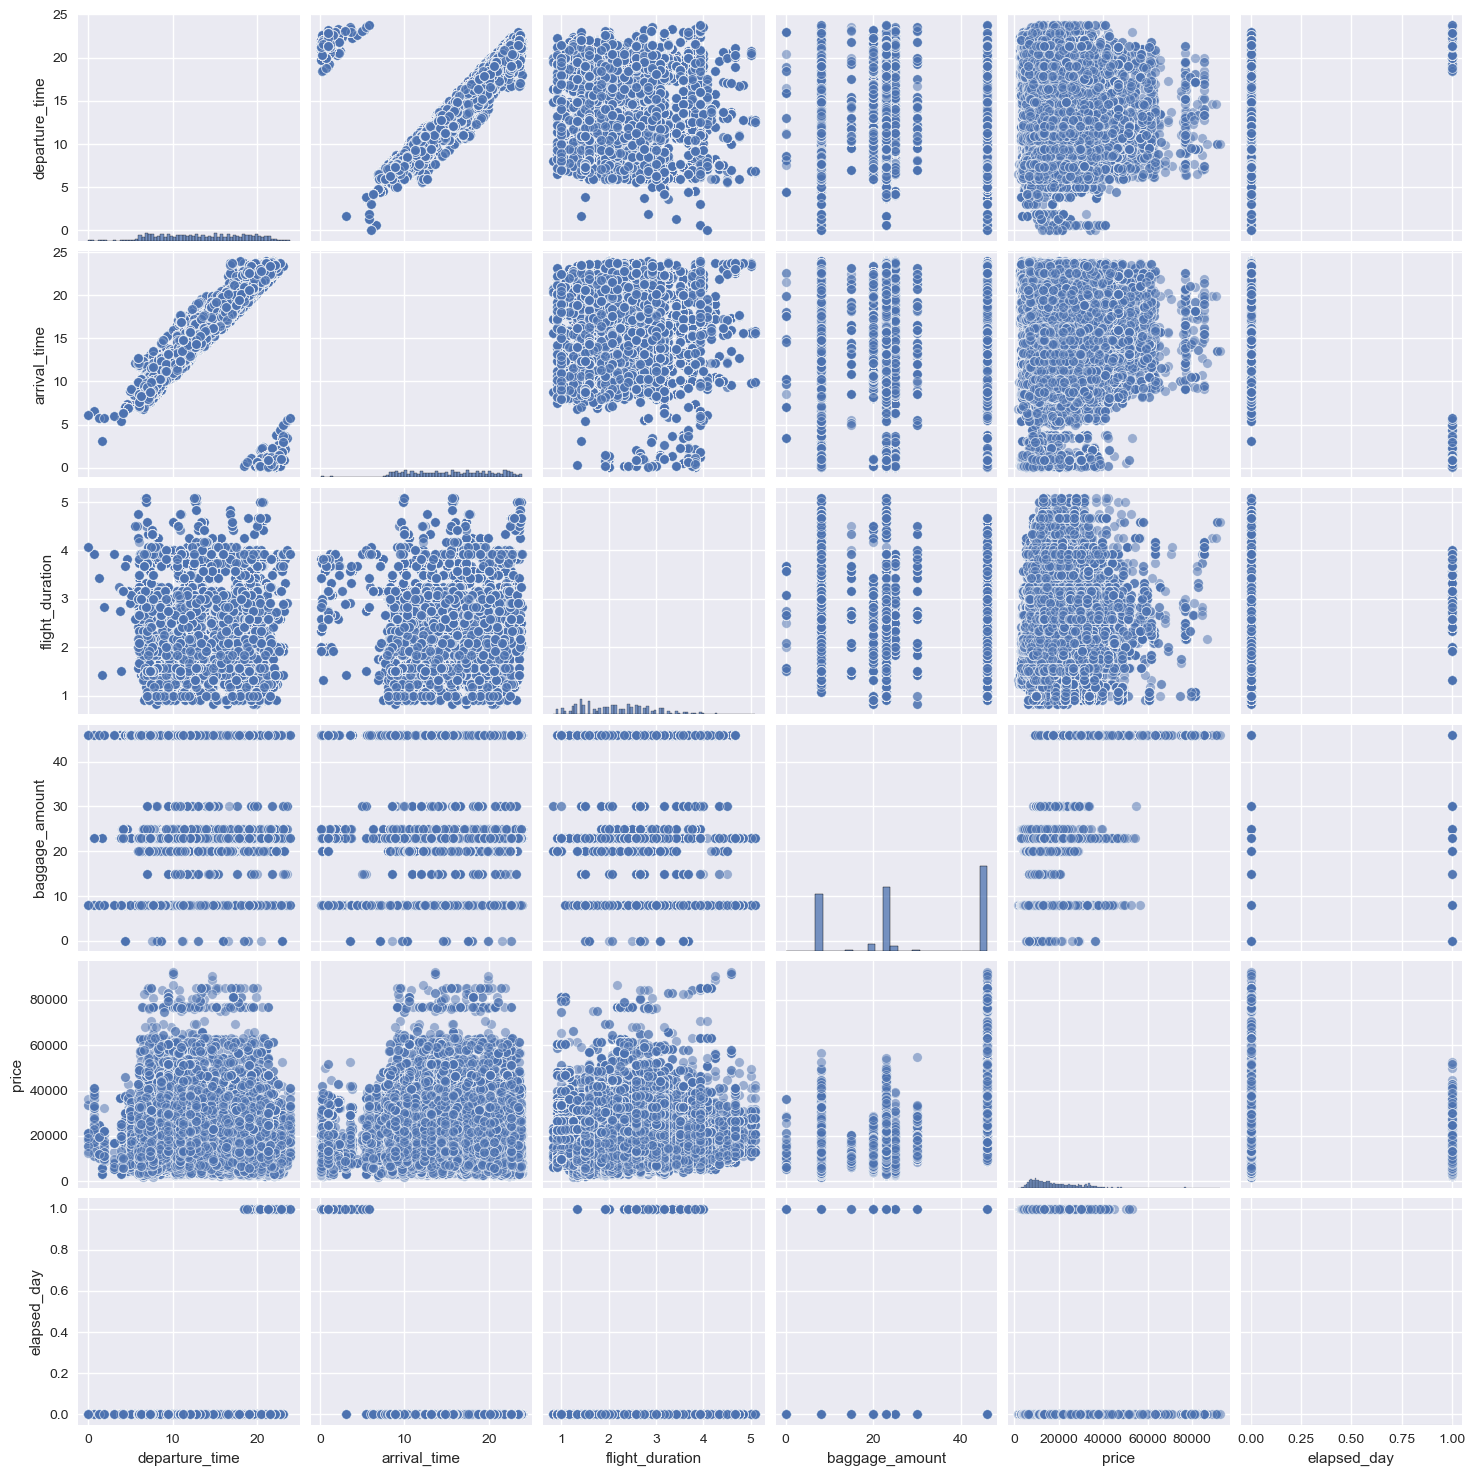

In [16]:
plt.figure(figsize=(10, 4))
sns.pairplot(df, plot_kws={'alpha': 0.5})


In [17]:
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,2026-04-14,1
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,2026-04-14,1
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,2026-04-14,1
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,2026-04-14,0
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,2026-04-14,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,2026-04-14,0
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,2026-04-14,0
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,2026-04-14,0
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,2026-04-14,0


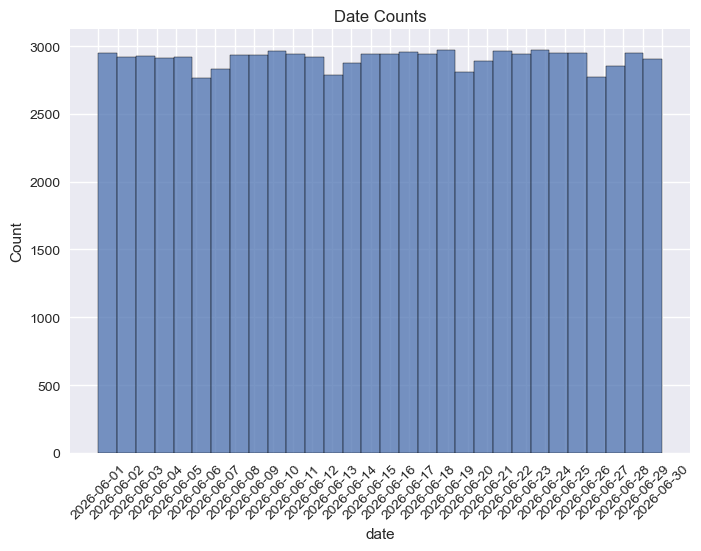

In [18]:
sns.histplot(df.date, bins=df.date.nunique())
plt.xticks(df.date.unique(), rotation=45)
plt.title("Date Counts");


Text(0.5, 1.0, 'Airline Counts')

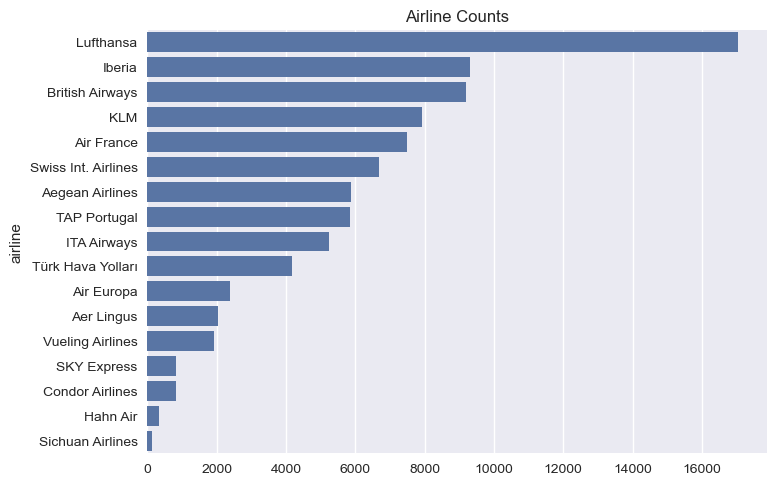

In [19]:
airline_counts = df.airline.value_counts()
sns.barplot(x=airline_counts.values, y=airline_counts.index)
plt.title("Airline Counts")

Can make a "*Others*" group for airlines which have less flight counts.

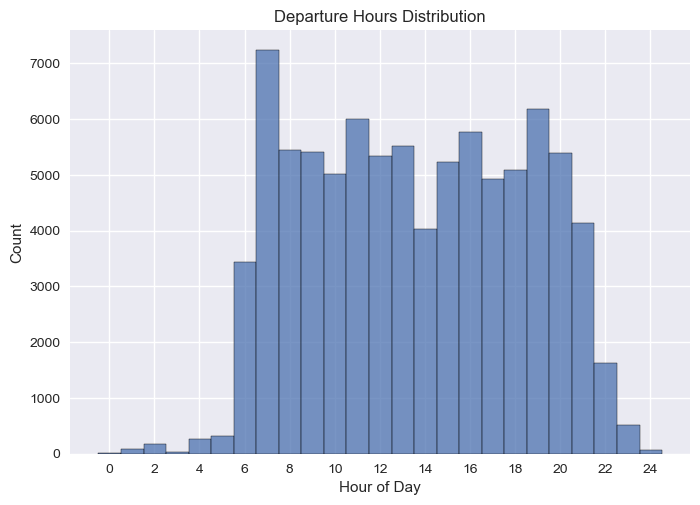

In [20]:
sns.histplot(df.departure_time, bins=24, discrete=True) # "Discrete=True" parameter aligns the ticks with the middle of the bins
plt.xticks(range(0, 25, 2))
plt.xlabel("Hour of Day")
plt.title("Departure Hours Distribution");

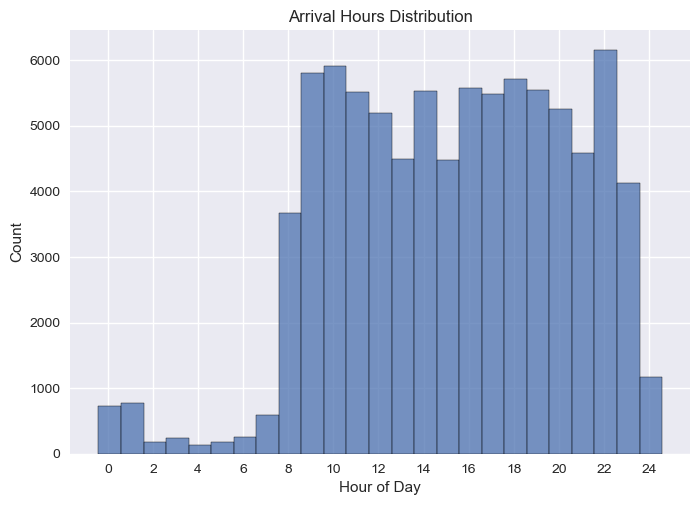

In [21]:
sns.histplot(df.arrival_time, bins=24, discrete=True)
plt.xticks(range(0,25,2))
plt.xlabel("Hour of Day")
plt.title("Arrival Hours Distribution");

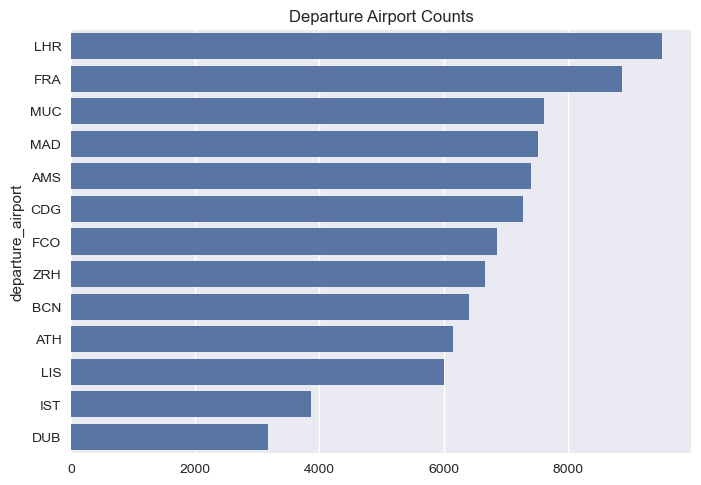

In [22]:
departure_airports = df.departure_airport.value_counts()
sns.barplot(x=departure_airports.values, y=departure_airports.index)
plt.title("Departure Airport Counts");

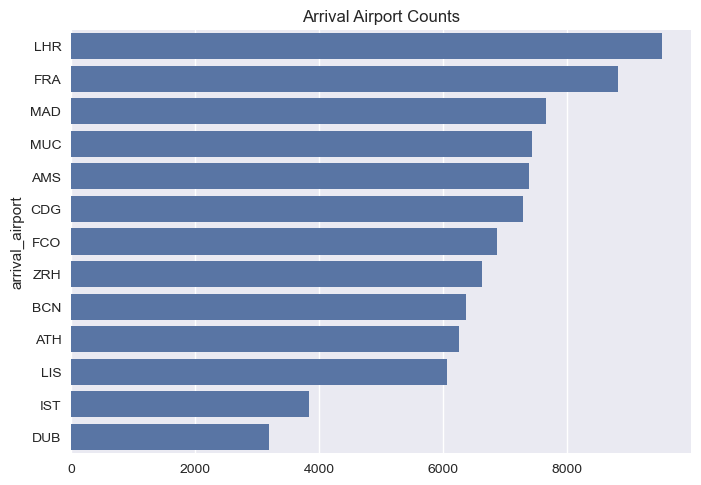

In [23]:
arrival_airports = df.arrival_airport.value_counts()
sns.barplot(x=arrival_airports.values, y=arrival_airports.index)
plt.title("Arrival Airport Counts");

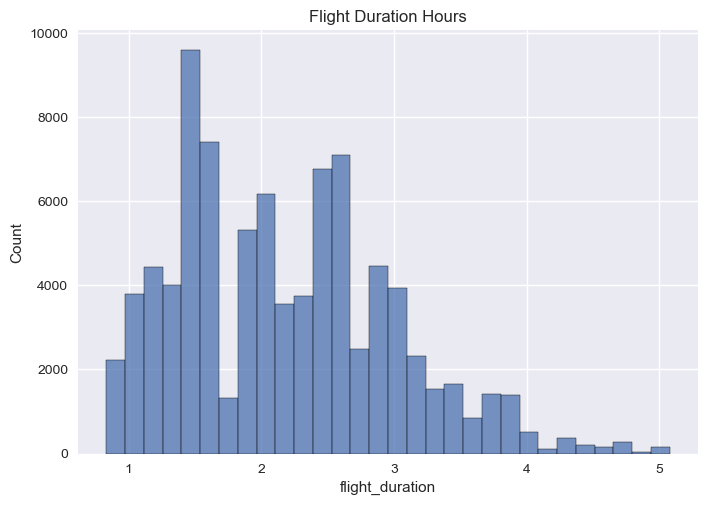

In [24]:
sns.histplot(df.flight_duration, bins=30)
plt.title("Flight Duration Hours");

As we can see flight duration distribution is right skewed. Thus we can do log transform later on.

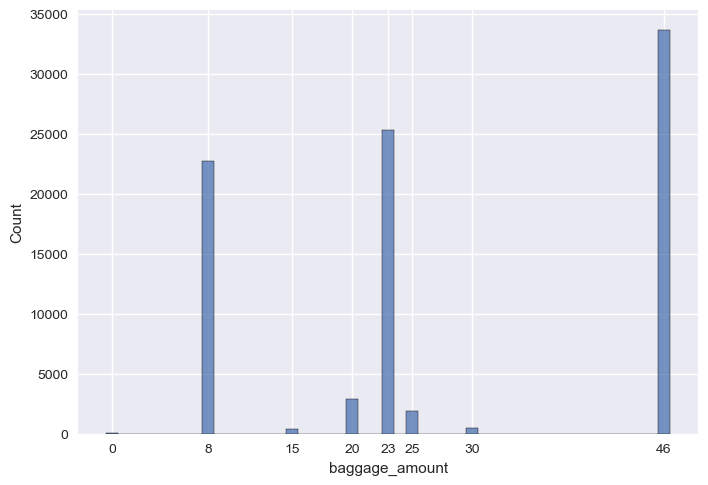

In [25]:
sns.histplot(df.baggage_amount, discrete=True)
plt.xticks(df.baggage_amount.unique());

There are 2 options in my mind.
1) Leave them as numerical values. Do the scaling transform only.
2) Turn them into a categorical value such as "low","medium","high" 

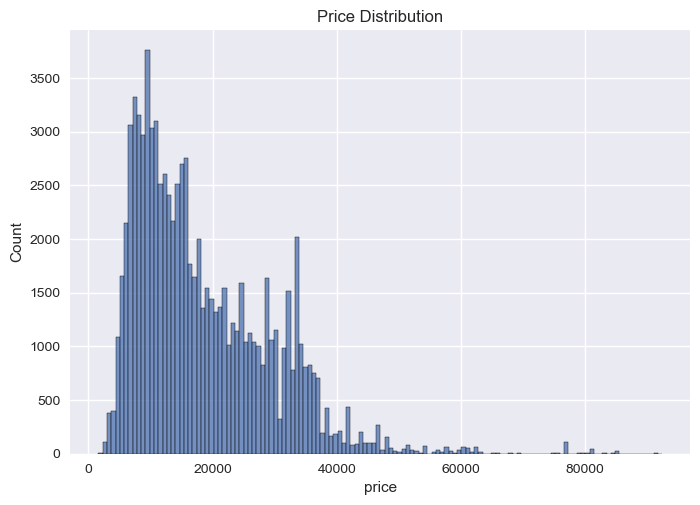

In [26]:
sns.histplot(df.price)
plt.title("Price Distribution");

It can be clearly seen that price distribution is right-skewed. Thus we need to take the log(price) and inverse transform it after the model predicts.

## Feature Engineering

In [27]:
df_cleaned = df # Don't run this again

In [28]:
df = df_cleaned.copy() # Run this instead

In [29]:
df["days_to_flight"] = (df.date - df.scraping_date).dt.days
df
# Adding a feature that represents how many days are left to the flight

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day,days_to_flight
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,2026-04-14,1,54
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,2026-04-14,1,54
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,2026-04-14,1,54
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,2026-04-14,0,54
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,2026-04-14,0,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,2026-04-14,0,67
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,2026-04-14,0,67
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,2026-04-14,0,67
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,2026-04-14,0,67


In [30]:
df["day_of_week"] = df.date.dt.day_of_week
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day,days_to_flight,day_of_week
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,2026-04-14,1,54,6
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,2026-04-14,1,54,6
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,2026-04-14,1,54,6
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,2026-04-14,0,54,6
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,2026-04-14,0,54,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,2026-04-14,0,67,5
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,2026-04-14,0,67,5
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,2026-04-14,0,67,5
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,2026-04-14,0,67,5


In [31]:
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day,days_to_flight,day_of_week,is_weekend
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,2026-04-14,1,54,6,1
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,2026-04-14,1,54,6,1
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,2026-04-14,1,54,6,1
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,2026-04-14,0,67,5,1
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,2026-04-14,0,67,5,1
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,2026-04-14,0,67,5,1
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,2026-04-14,0,67,5,1


In [32]:
df.departure_airport.value_counts()

departure_airport
LHR    9508
FRA    8875
MUC    7623
MAD    7518
AMS    7401
CDG    7271
FCO    6853
ZRH    6658
BCN    6400
ATH    6154
LIS    5998
IST    3864
DUB    3172
Name: count, dtype: int64

### Holidays and Major Events
    LHR = 25 May Spring Bank Holiday, 29-30 June Wimbledon
    IST = -
    BCN = 3-7 June Primavera Sound
    MAD = -
    MUC = 4 June Corpus Christi
    FRA = -
    FCO = 2 June Festa della Repubblica
    DUB = 1 June June Bank Holiday
    LIS = 10 June Portugal Day, 13 June St. Anthony's Day
    ATH = 1 June Pentecost Monday
    CDG = -
    AMS = -
    ZRH = -

In [33]:
holiday_dict = {"LHR":["2026-05-25","2026-06-29","2026-06-30"],
                "IST":[],
                "BCN":["2026-06-03","2026-06-04","2026-06-05","2026-06-06","2026-06-07"],
                "MAD":[],
                "MUC":["2026-06-04"],
                "FRA":[],
                "FCO":["2026-06-02"],
                "DUB":["2026-06-01"],
                "LIS":["2026-06-10","2026-06-13"],
                "ATH":["2026-06-01"],
                "CDG":[],
                "AMS":[],
                "ZRH":[] }

In [34]:
holiday_dict = {key: pd.to_datetime(value) for key, value in holiday_dict.items()}

In [35]:
holiday_dict

{'LHR': DatetimeIndex(['2026-05-25', '2026-06-29', '2026-06-30'], dtype='datetime64[ns]', freq=None),
 'IST': DatetimeIndex([], dtype='datetime64[ns]', freq=None),
 'BCN': DatetimeIndex(['2026-06-03', '2026-06-04', '2026-06-05', '2026-06-06',
                '2026-06-07'],
               dtype='datetime64[ns]', freq=None),
 'MAD': DatetimeIndex([], dtype='datetime64[ns]', freq=None),
 'MUC': DatetimeIndex(['2026-06-04'], dtype='datetime64[ns]', freq=None),
 'FRA': DatetimeIndex([], dtype='datetime64[ns]', freq=None),
 'FCO': DatetimeIndex(['2026-06-02'], dtype='datetime64[ns]', freq=None),
 'DUB': DatetimeIndex(['2026-06-01'], dtype='datetime64[ns]', freq=None),
 'LIS': DatetimeIndex(['2026-06-10', '2026-06-13'], dtype='datetime64[ns]', freq=None),
 'ATH': DatetimeIndex(['2026-06-01'], dtype='datetime64[ns]', freq=None),
 'CDG': DatetimeIndex([], dtype='datetime64[ns]', freq=None),
 'AMS': DatetimeIndex([], dtype='datetime64[ns]', freq=None),
 'ZRH': DatetimeIndex([], dtype='datetime64

In [36]:
holiday_dict["LHR"]

DatetimeIndex(['2026-05-25', '2026-06-29', '2026-06-30'], dtype='datetime64[ns]', freq=None)

In [37]:
np.abs(df.loc[0].date - holiday_dict[df.loc[0].departure_airport]).min() # Getting min_days_to_holiday for one row

Timedelta('13 days 00:00:00')

In [38]:
def min_days_to_event(date, airport):
    dates = holiday_dict[airport]

    if len(dates) == 0:
        return np.nan
    
    return np.abs((date - dates).days).min()

In [39]:
df["days_to_holiday_dep"] = df.apply(lambda x: min_days_to_event(x["date"], x["departure_airport"]), axis=1)
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day,days_to_flight,day_of_week,is_weekend,days_to_holiday_dep
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,2026-04-14,1,54,6,1,13.0
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,2026-04-14,1,54,6,1,13.0
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,2026-04-14,1,54,6,1,13.0
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1,13.0
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,2026-04-14,0,67,5,1,NaN
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,2026-04-14,0,67,5,1,NaN
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,2026-04-14,0,67,5,1,NaN
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,2026-04-14,0,67,5,1,NaN


In [40]:
df["days_to_holiday_arr"] = df.apply(lambda x: min_days_to_event(x["date"], x["arrival_airport"]), axis=1)
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day,days_to_flight,day_of_week,is_weekend,days_to_holiday_dep,days_to_holiday_arr
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,2026-04-14,1,54,6,1,13.0,NaN
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,2026-04-14,1,54,6,1,13.0,NaN
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,2026-04-14,1,54,6,1,13.0,NaN
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1,13.0,NaN
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1,13.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,2026-04-14,0,67,5,1,NaN,19.0
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,2026-04-14,0,67,5,1,NaN,19.0
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,2026-04-14,0,67,5,1,NaN,19.0
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,2026-04-14,0,67,5,1,NaN,19.0


I will take the exponential of the *days_to_holiday_dep* and *days_to_holiday_arr*
Since np.nan values are at least 30 days apart from the nearest holiday, I will fill them with 30
They will have near 0 values at the end of the transformation

In [41]:
df.days_to_holiday_dep = df.days_to_holiday_dep.fillna(30)
df.days_to_holiday_arr = df.days_to_holiday_arr.fillna(30) 
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day,days_to_flight,day_of_week,is_weekend,days_to_holiday_dep,days_to_holiday_arr
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,2026-04-14,1,54,6,1,13.0,30.0
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,2026-04-14,1,54,6,1,13.0,30.0
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,2026-04-14,1,54,6,1,13.0,30.0
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1,13.0,30.0
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1,13.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,2026-04-14,0,67,5,1,30.0,19.0
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,2026-04-14,0,67,5,1,30.0,19.0
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,2026-04-14,0,67,5,1,30.0,19.0
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,2026-04-14,0,67,5,1,30.0,19.0


In [42]:
np.exp(-df.days_to_holiday_dep/3).value_counts()

days_to_holiday_dep
0.000045    41587
1.000000     2897
0.716531     2826
0.513417     2176
0.096972     2051
0.069483     2035
0.049787     2024
0.367879     1974
0.025562     1877
0.035674     1861
0.003459     1861
0.009404     1845
0.006738     1843
0.018316     1835
0.004828     1833
0.013124     1833
0.263597     1716
0.188876     1696
0.135335     1695
0.002479     1022
0.000653     1018
0.000468     1011
0.000912     1010
0.001273     1000
0.001776      995
0.000240      809
0.000335      791
0.000172      775
0.000088      553
0.000123      544
0.000063      302
Name: count, dtype: int64

In [43]:
df.days_to_holiday_dep = np.exp(-df.days_to_holiday_dep/3)
df.days_to_holiday_arr = np.exp(-df.days_to_holiday_arr/3)
df

,date,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,scraping_date,elapsed_day,days_to_flight,day_of_week,is_weekend,days_to_holiday_dep,days_to_holiday_arr
0,2026-06-07,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,2026-04-14,1,54,6,1,0.013124,0.000045
1,2026-06-07,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,2026-04-14,1,54,6,1,0.013124,0.000045
2,2026-06-07,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,2026-04-14,1,54,6,1,0.013124,0.000045
3,2026-06-07,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1,0.013124,0.000045
4,2026-06-07,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,2026-04-14,0,54,6,1,0.013124,0.000045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87290,2026-06-20,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,2026-04-14,0,67,5,1,0.000045,0.001776
87291,2026-06-20,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,2026-04-14,0,67,5,1,0.000045,0.001776
87292,2026-06-20,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,2026-04-14,0,67,5,1,0.000045,0.001776
87293,2026-06-20,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,2026-04-14,0,67,5,1,0.000045,0.001776


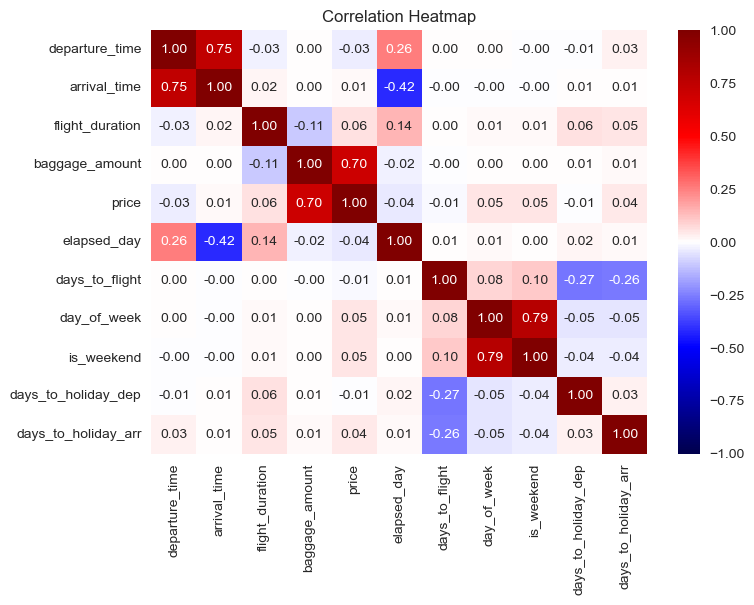

In [44]:
df_correlations = df.select_dtypes(include=[int, float]).corr()
sns.heatmap(df_correlations, vmin=-1, vmax=1, cmap="seismic", cbar=True, annot=True, fmt=".2f")
plt.title("Correlation Heatmap");

Text(0.5, 1.0, 'Median Price per Date')

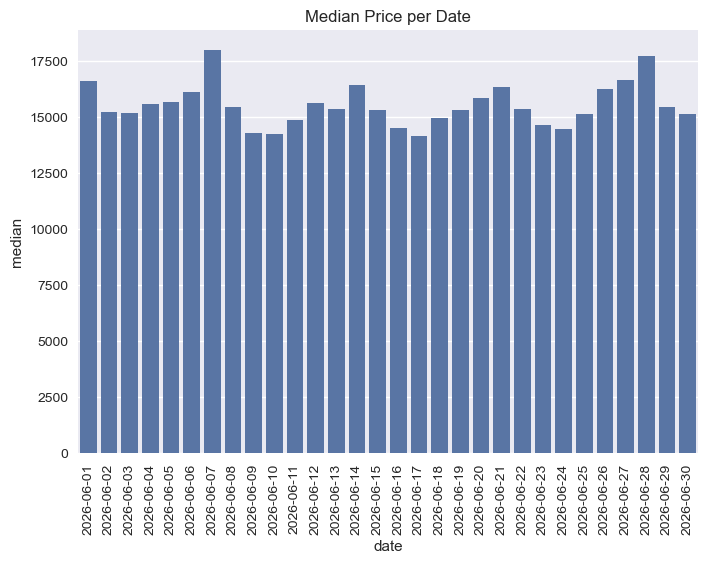

In [45]:
date_price = df.groupby("date")["price"].agg(["mean","median","count"]).reset_index()
date_price
sns.barplot(data=date_price, x="date", y="median")
plt.xticks(rotation=90)
plt.title("Median Price per Date")

## Preprocessing

In [46]:
df_feature_engineered = df # Don't run this again

In [47]:
df = df_feature_engineered.copy() # Run this instead

First of all, before preprocessing we need to split our test set by using *time series split*. But since we will divide our set once, we won't use the function.

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87295 entries, 0 to 87294
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 87295 non-null  datetime64[ns]
 1   airline              87295 non-null  object        
 2   class_type           87295 non-null  object        
 3   departure_time       87295 non-null  float64       
 4   arrival_time         87295 non-null  float64       
 5   departure_airport    87295 non-null  object        
 6   arrival_airport      87295 non-null  object        
 7   flight_duration      87295 non-null  float64       
 8   baggage_amount       87295 non-null  int64         
 9   price                87295 non-null  int64         
 10  scraping_date        87295 non-null  datetime64[ns]
 11  elapsed_day          87295 non-null  int64         
 12  days_to_flight       87295 non-null  int64         
 13  day_of_week          87295 non-null 

In [49]:
df["day"] = df.date.dt.day.astype(int)
df = df.drop(["date","scraping_date"], axis=1) # I don't need them anymore
df

,airline,class_type,departure_time,arrival_time,departure_airport,arrival_airport,flight_duration,baggage_amount,price,elapsed_day,days_to_flight,day_of_week,is_weekend,days_to_holiday_dep,days_to_holiday_arr,day
0,British Airways,Ekonomi,19.08,0.92,LHR,IST,3.83,8,8128,1,54,6,1,0.013124,0.000045,7
1,Türk Hava Yolları,Ekonomi,22.67,4.33,LHR,IST,3.67,8,8642,1,54,6,1,0.013124,0.000045,7
2,Türk Hava Yolları,Ekonomi,18.50,0.25,LHR,IST,3.75,8,8642,1,54,6,1,0.013124,0.000045,7
3,Türk Hava Yolları,Ekonomi,13.33,19.17,LHR,IST,3.83,8,8642,0,54,6,1,0.013124,0.000045,7
4,Türk Hava Yolları,Ekonomi,16.75,22.58,LHR,IST,3.83,8,8642,0,54,6,1,0.013124,0.000045,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87290,Swiss Int. Airlines,Business,12.08,15.75,ZRH,ATH,2.67,46,37775,0,67,5,1,0.000045,0.001776,20
87291,Swiss Int. Airlines,Business,16.58,20.17,ZRH,ATH,2.58,46,37775,0,67,5,1,0.000045,0.001776,20
87292,Aegean Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,44076,0,67,5,1,0.000045,0.001776,20
87293,Swiss Int. Airlines,Business,11.25,14.83,ZRH,ATH,2.58,46,51095,0,67,5,1,0.000045,0.001776,20


#### Test Data Time Split

In [50]:
df = df.sort_values(["day","departure_time","flight_duration"]).reset_index(drop=True)
split_index = int(len(df) * 0.8)
train = df.iloc[:split_index]
X_train = train.drop("price", axis=1)
y_train = train.price
test = df.iloc[split_index:]
X_test = test.drop("price", axis=1)
y_test = test.price
print(f"Our train set has {len(train)} rows and test set has {len(test)} rows, total of {len(df)} rows.")

Our train set has 69836 rows and test set has 17459 rows, total of 87295 rows.


After that, we will do deterministic transformations

#### Deterministic Transformation

In [51]:
def sin_cos_transform(column, period):
    col_values = column.values
    sin_values = np.sin(2*np.pi*col_values/period)
    cos_values = np.cos(2*np.pi*col_values/period)
    return np.column_stack([sin_values,cos_values])

We need to define the names of newly created sin and cos column names for each variable that will use this transformation

In [52]:
def sin_cos_names(transformer, feature_names_in):
    col_name = feature_names_in[0] # We must add [0] since the format of feature_names_in is np.array
    return [f"{col_name}_sin", f"{col_name}_cos"]

In [53]:
sin_cos_names(sin_cos_transform, np.array(["departure_time"]))

['departure_time_sin', 'departure_time_cos']

In [54]:
def log_names(transformer, feature_names_in):
    col_name = feature_names_in[0]
    return [f"{col_name}_log"]

In [55]:
hour_transformer = FunctionTransformer(sin_cos_transform, kw_args={"period": 24}, feature_names_out=sin_cos_names)
day_transformer = FunctionTransformer(sin_cos_transform, kw_args={"period": 7}, feature_names_out=sin_cos_names)
log_transformer = FunctionTransformer(np.log, feature_names_out=log_names)

In [56]:
deterministic_transformer = ColumnTransformer(transformers=[("departure_time", hour_transformer, ["departure_time"]),
                                                            ("arrival_time", hour_transformer, ["arrival_time"]),
                                                            ("weekday_transform", day_transformer, ["day_of_week"]),
                                                            ("log_transform", log_transformer, ["flight_duration"])],
                                                            remainder="passthrough",
                                                            verbose_feature_names_out=False).set_output(transform="pandas")
# We will log transform price by using TransformedTargetRegressor, so I will not include price in this Column Transformer

In [57]:
deterministic_transformer

,transformers,"[('departure_time', ...), ('arrival_time', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,func,<function sin...002621AF9A840>
,inverse_func,None
,validate,False


In [58]:
deterministic_transformer.fit_transform(X_train)
deterministic_transformer.transform(X_test)
# Our deterministic_transform is working

,departure_time_sin,departure_time_cos,arrival_time_sin,arrival_time_cos,day_of_week_sin,day_of_week_cos,flight_duration_log,airline,class_type,departure_airport,arrival_airport,baggage_amount,elapsed_day,days_to_flight,is_weekend,days_to_holiday_dep,days_to_holiday_arr,day
69836,-0.592013,0.805928,0.044491,0.999010,0.974928,-0.222521,0.947789,ITA Airways,Ekonomi,FCO,MAD,8,1,71,0,0.000653,0.000045,24
69837,-0.592013,0.805928,0.044491,0.999010,0.974928,-0.222521,0.947789,ITA Airways,Business,FCO,MAD,46,1,71,0,0.000653,0.000045,24
69838,-0.592013,0.805928,-0.044491,0.999010,0.974928,-0.222521,1.178655,Vueling Airlines,Ekonomi,ATH,BCN,25,0,71,0,0.000468,0.003459,24
69839,-0.592013,0.805928,-0.044491,0.999010,0.974928,-0.222521,1.178655,Iberia,Ekonomi,ATH,BCN,23,0,71,0,0.000468,0.003459,24
69840,-0.592013,0.805928,0.109734,0.993961,0.974928,-0.222521,1.342865,Aegean Airlines,Ekonomi,ATH,MAD,8,1,71,0,0.000468,0.000045,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87290,-0.174508,0.984656,0.819652,0.572861,0.781831,0.623490,1.202972,Türk Hava Yolları,Ekonomi,AMS,IST,8,1,77,0,0.000045,0.000045,30
87291,-0.044491,0.999010,0.997859,0.065403,0.781831,0.623490,1.366092,Aegean Airlines,Ekonomi,LIS,ATH,8,1,77,0,0.003459,0.000063,30
87292,-0.044491,0.999010,0.997859,0.065403,0.781831,0.623490,1.366092,TAP Portugal,Ekonomi,LIS,ATH,23,1,77,0,0.003459,0.000063,30
87293,-0.044491,0.999010,0.997859,0.065403,0.781831,0.623490,1.366092,Aegean Airlines,Business,LIS,ATH,46,1,77,0,0.003459,0.000063,30


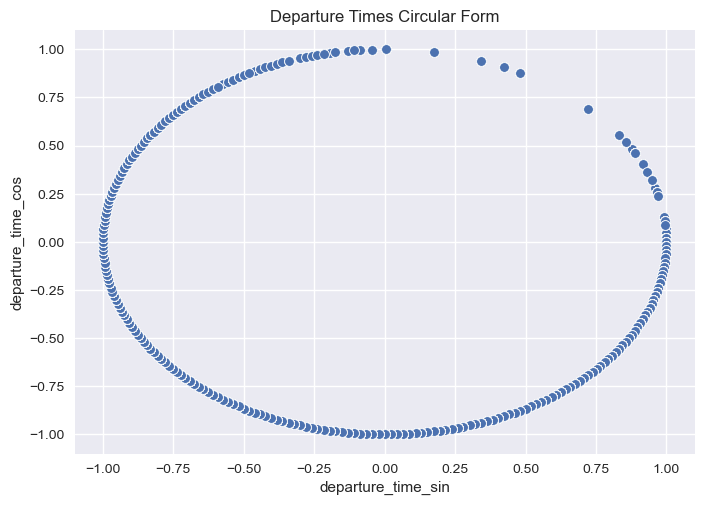

In [59]:
sns.scatterplot(data=deterministic_transformer.fit_transform(X_train), x="departure_time_sin", y="departure_time_cos")
plt.title("Departure Times Circular Form");

As we can see, our transformations worked.

#### Encoding and Scaling with Pipelines

Now that we know all the generated column names, we can make lists of column names and give them to pipelines

In [60]:
deterministic_transformer.fit_transform(X_train).info()
deterministic_transformer.get_feature_names_out()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69836 entries, 0 to 69835
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   departure_time_sin   69836 non-null  float64
 1   departure_time_cos   69836 non-null  float64
 2   arrival_time_sin     69836 non-null  float64
 3   arrival_time_cos     69836 non-null  float64
 4   day_of_week_sin      69836 non-null  float64
 5   day_of_week_cos      69836 non-null  float64
 6   flight_duration_log  69836 non-null  float64
 7   airline              69836 non-null  object 
 8   class_type           69836 non-null  object 
 9   departure_airport    69836 non-null  object 
 10  arrival_airport      69836 non-null  object 
 11  baggage_amount       69836 non-null  int64  
 12  elapsed_day          69836 non-null  int64  
 13  days_to_flight       69836 non-null  int64  
 14  is_weekend           69836 non-null  int64  
 15  days_to_holiday_dep  69836 non-null 

array(['departure_time_sin', 'departure_time_cos', 'arrival_time_sin',
       'arrival_time_cos', 'day_of_week_sin', 'day_of_week_cos',
       'flight_duration_log', 'airline', 'class_type',
       'departure_airport', 'arrival_airport', 'baggage_amount',
       'elapsed_day', 'days_to_flight', 'is_weekend',
       'days_to_holiday_dep', 'days_to_holiday_arr', 'day'], dtype=object)

In [61]:
X_train_transformed = deterministic_transformer.fit_transform(X_train) # To give the newly created column names to pipelines, I need to do this step.
OHE_columns = ["airline","departure_airport","arrival_airport"]
ordinal_column = ["class_type"]
num_columns = X_train_transformed.select_dtypes(exclude="object").columns.to_list()

Now lets create pipelines for our numerical and categorical columns

In [62]:
OHE_pipeline = Pipeline(steps= [("Encoding", OneHotEncoder(drop="first", sparse_output=False))])

In [63]:
ordinal_pipeline = Pipeline(steps= [("Encoding", OrdinalEncoder(categories=[["Ekonomi","Business"]]))])

In [64]:
num_pipeline = Pipeline(steps= [("Scaling", StandardScaler())])

In [65]:
ct = ColumnTransformer(transformers=[("OHE", OHE_pipeline, OHE_columns),
                                     ("ordinal", ordinal_pipeline, ordinal_column),
                                     ("num", num_pipeline, num_columns)],
                                     verbose_feature_names_out=False).set_output(transform="pandas")

#### Last Analysis Before Calling and Fitting the Model

In [66]:
transformed_pipeline = Pipeline(steps=[("deterministic", deterministic_transformer),
                                       ("encoding_scaling", ct)])

In [67]:
transformed_pipeline

,steps,"[('deterministic', ...), ('encoding_scaling', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('departure_time', ...), ('arrival_time', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [68]:
X_transformed = transformed_pipeline.fit_transform(X_train)

<Axes: >

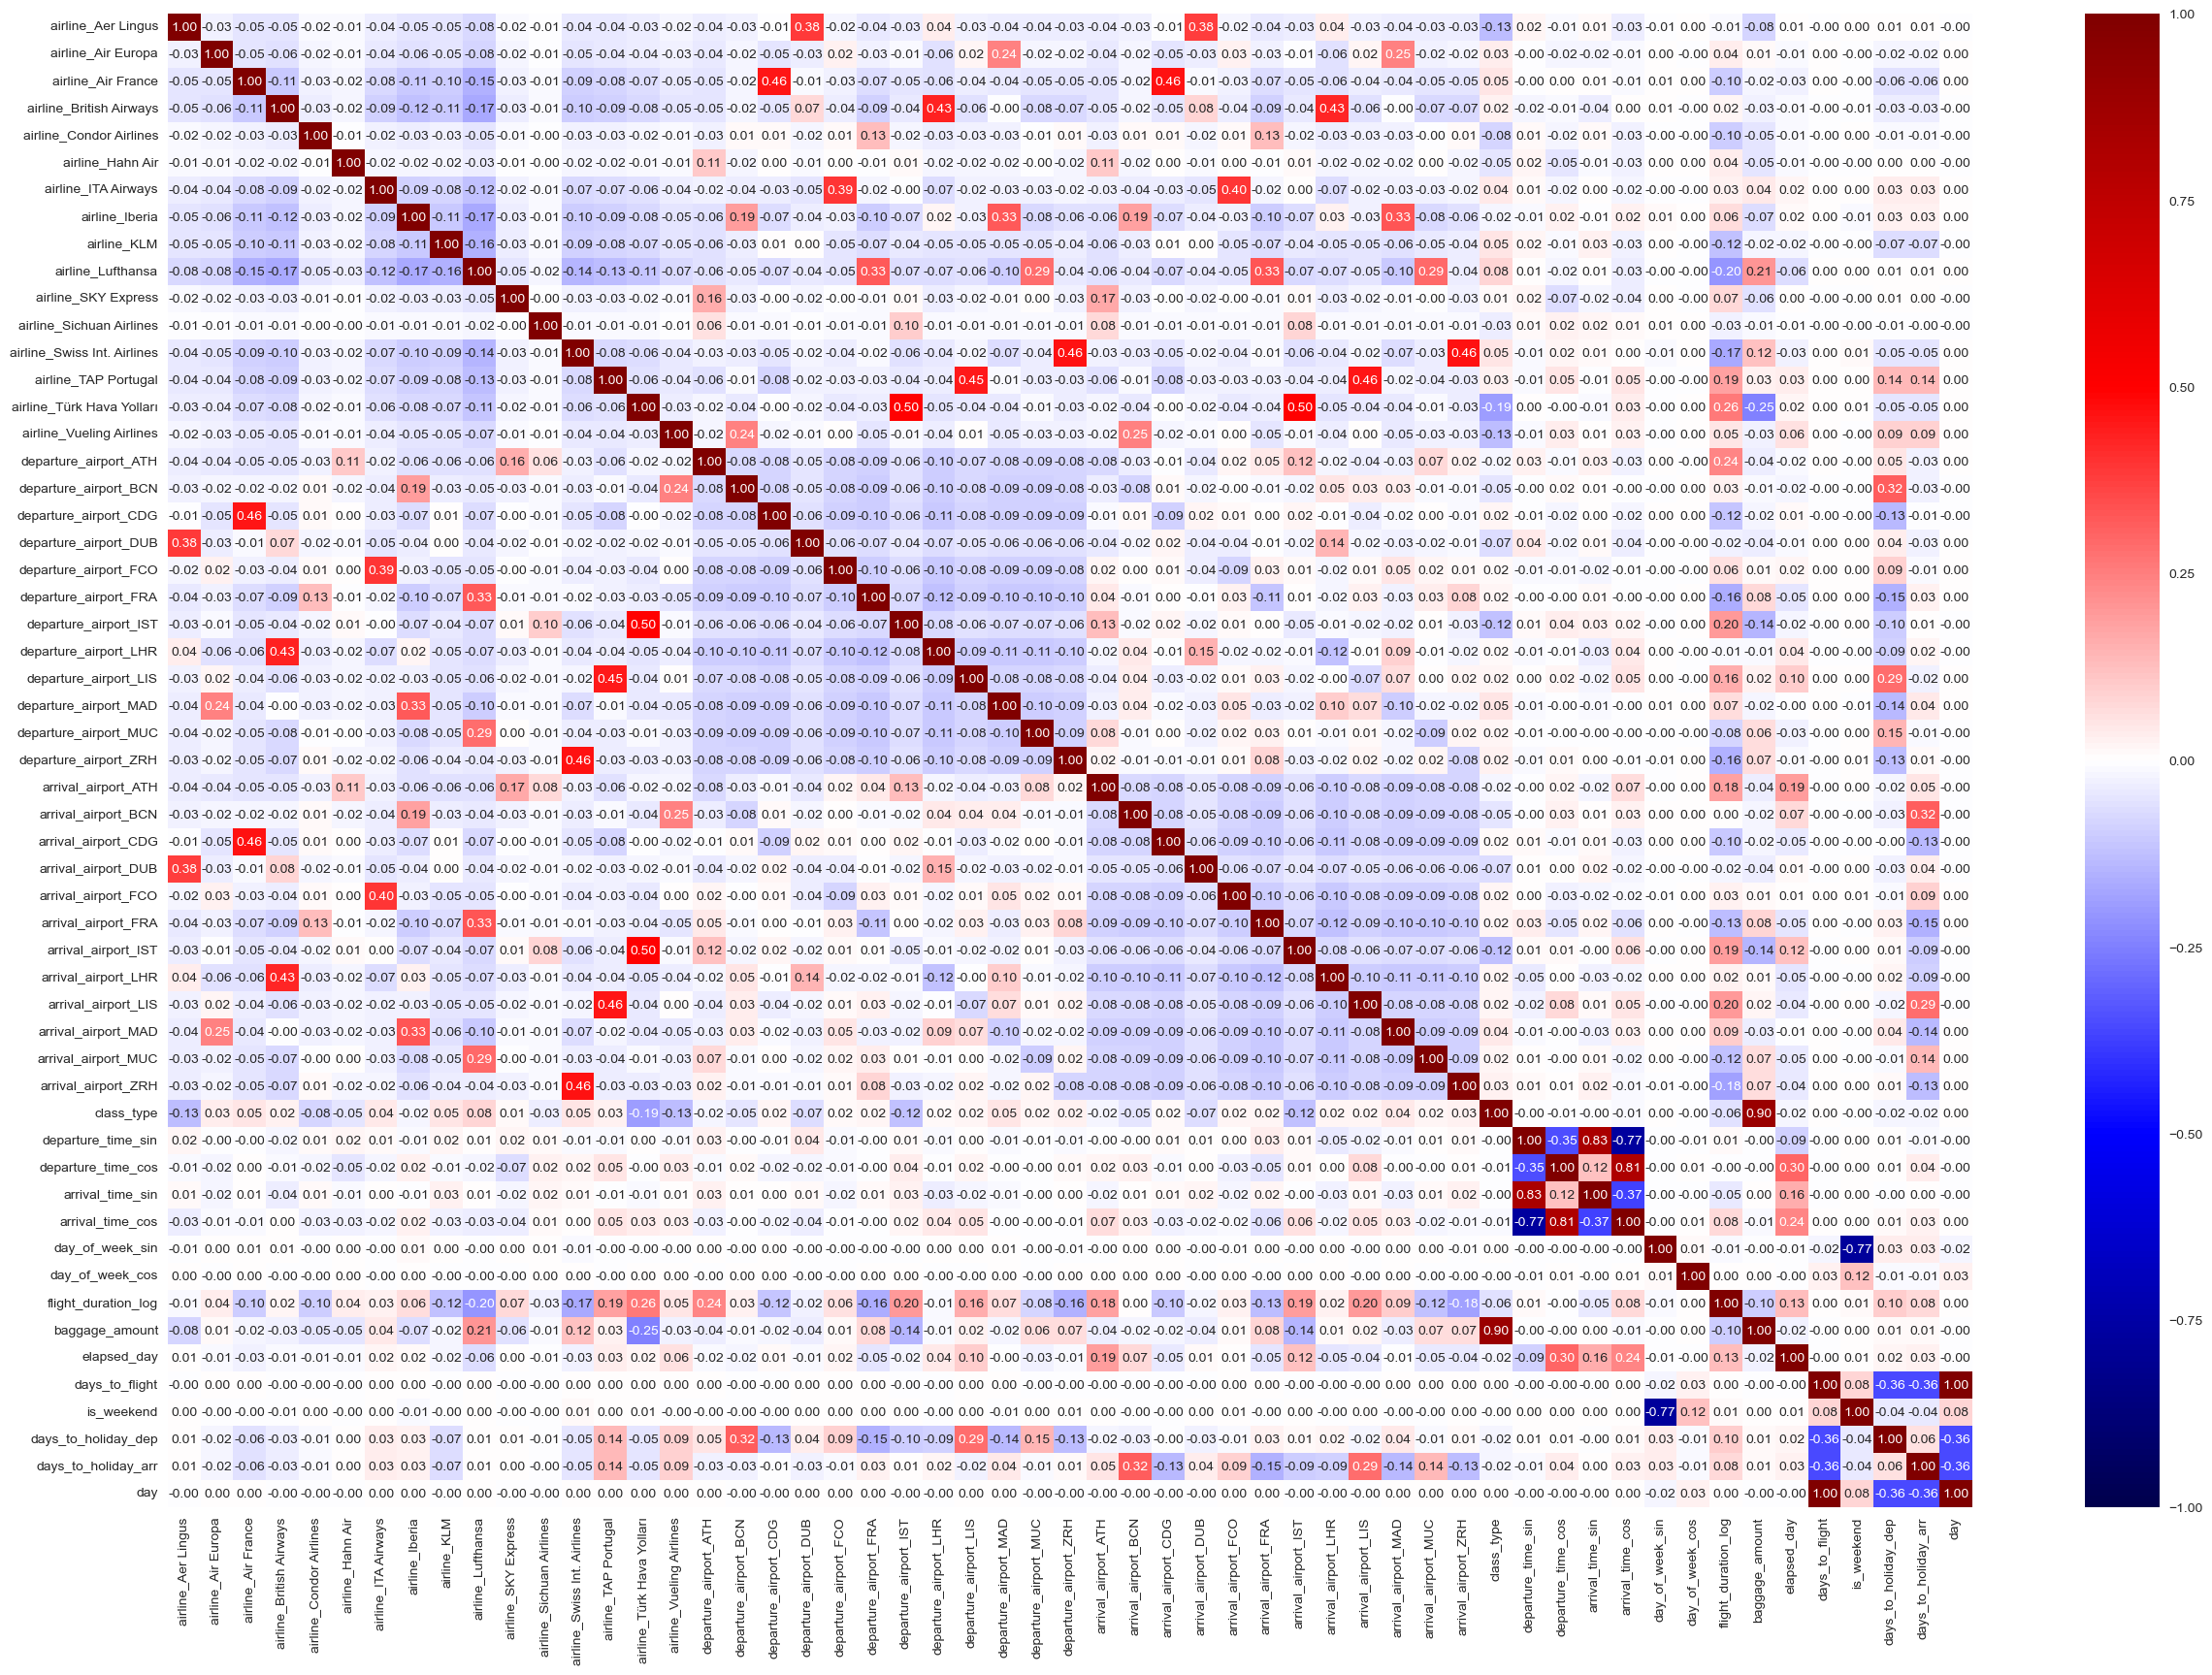

In [69]:
plt.figure(figsize=(30,20))
sns.heatmap(data=X_transformed.corr(), vmin=-1, vmax=1, cmap="seismic", annot=True, fmt=".2f", cbar=True)

#### Highest Correlations After Preprocessing:
1) *baggage_amount* and *class_type* = 0.90
2) *departure_time sin-cos* and *arrival_time sin-cos* = around 0.75
3) *is_weekend* and *day_of_week_sin* = -0.77
4) *day* and *days_to_flight* = 1

We need to drop one of the highly correlated columns to prevent *Multicollinearity*

In [70]:
X_train = X_train.drop(["baggage_amount", "arrival_time", "is_weekend", "day"], axis=1)
X_test = X_test.drop(["baggage_amount", "arrival_time", "is_weekend", "day"], axis=1)

In [71]:
deterministic_transformer_final = ColumnTransformer(transformers=[("departure_time", hour_transformer, ["departure_time"]),
                                                                  ("weekday_transform", day_transformer, ["day_of_week"]),
                                                                  ("log_transform", log_transformer, ["flight_duration"])],
                                                                  remainder="passthrough",
                                                                  verbose_feature_names_out=False).set_output(transform="pandas")
# Since earlier deterministic_transformer transforms arrival_time column as well, we need to create new transformer without arrival_time step

In [72]:
X_train_transformed = deterministic_transformer_final.fit_transform(X_train) # To give the newly created column names to pipelines, I need to do this step.
OHE_columns = ["airline","departure_airport","arrival_airport"]
ordinal_column = ["class_type"]
num_columns = X_train_transformed.select_dtypes(exclude="object").columns.to_list()

In [73]:
ct = ColumnTransformer(transformers=[("OHE", OHE_pipeline, OHE_columns),
                                     ("ordinal", ordinal_pipeline, ordinal_column),
                                     ("num", num_pipeline, num_columns)],
                                     verbose_feature_names_out=False).set_output(transform="pandas")

#### Calling The Model and Creating Final Pipeline

In [74]:
price_log_transform = FunctionTransformer(func=np.log, inverse_func=np.exp)

In [75]:
model = TransformedTargetRegressor(regressor=LinearRegression(), 
                                   transformer=price_log_transform)

In [76]:
final_pipeline = Pipeline(steps=[("deterministic_final", deterministic_transformer_final),
                                 ("final_transformer", ct),
                                 ("model", model)])

#### Creating Validation Set

In [77]:
df = pd.concat([X_train, X_test])
df_transformed = df # Don't run this again

In [78]:
df = df_transformed.copy() # Run this instead

In [79]:
time_split = TimeSeriesSplit(n_splits=5)

In [80]:
folds = []
for fold, (train_idx, val_idx) in enumerate(time_split.split(X_train)):
    folds.append([fold+1, len(train_idx),len(val_idx)])
folds = pd.DataFrame(folds, columns=["fold", "train_size", "val_size"])
folds

,fold,train_size,val_size
0,1,11641,11639
1,2,23280,11639
2,3,34919,11639
3,4,46558,11639
4,5,58197,11639


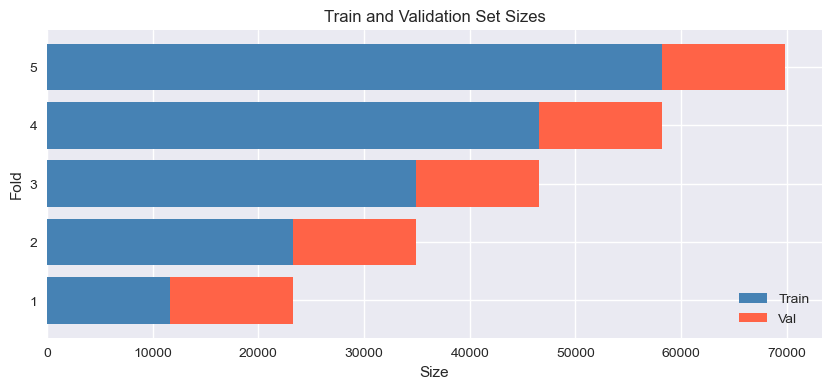

In [81]:
fig, ax = plt.subplots(figsize=(10, 4))

for row in range(len(folds)):
    plt.barh(folds['fold'][row], folds['train_size'][row], color='steelblue', label='Train' if row == 0 else "")
    plt.barh(folds['fold'][row], folds['val_size'][row], left=folds['train_size'][row], color='tomato', label='Val' if row == 0 else "")

plt.xlabel("Size")
plt.ylabel("Fold")
plt.legend()
plt.title("Train and Validation Set Sizes");

#### Comparing Models

##### TransformedTargetRegressor Results

In [82]:
scores = cross_val_score(final_pipeline, X_train, y_train, cv=time_split, scoring="neg_root_mean_squared_error")

rmse_scores = -scores
print(rmse_scores)
print(f"Mean RMSE value is: {rmse_scores.mean():.2f}")
print(f"Std: {rmse_scores.std():.2f}")

[11136.74778045  7206.01724759  7066.23356267  6536.52865148
  6474.68691297]
Mean RMSE value is: 7684.04
Std: 1749.90


In [83]:
r2_scores = cross_val_score(final_pipeline, X_train, y_train, cv=time_split, scoring="r2")

print(r2_scores)
print(f"Mean R2 value is: {r2_scores.mean():.2f}")
print(f"Std: {r2_scores.std():.2f}")

[0.05082231 0.56708098 0.57901719 0.61864069 0.61778323]
Mean R2 value is: 0.49
Std: 0.22


In [84]:
results = []

results.append({
    'model': 'Transformed_Target_Regression_(Baseline)',
    'mean_r2': 0.49,
    'std_r2': 0.22,
    'mean_rmse': 7684,
    'std_rmse': 1750
})

results_df = pd.DataFrame(results)

##### LinearRegression Results

In [85]:
lr = LinearRegression()

lr_pipeline = Pipeline(steps=[("deterministic_final", deterministic_transformer_final),
                                 ("final_transformer", ct),
                                 ("model", lr)])

In [86]:
scores = cross_val_score(lr_pipeline, X_train, y_train, cv=time_split, scoring="neg_root_mean_squared_error")

rmse_scores = -scores
print(rmse_scores)
print(f"Mean RMSE value: {rmse_scores.mean():.2f}")
print(f"Std: {rmse_scores.std():.2f}")

[12714.44573116  7119.95347789  6941.8879483   6465.57856252
  6374.87801938]
Mean RMSE value: 7923.35
Std: 2411.89


In [87]:
r2_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=time_split, scoring="r2")

print(r2_scores)
print(f"Mean R2 value is: {r2_scores.mean():.2f}")
print(f"Std: {r2_scores.std():.2f}")

[-0.23715928  0.57736021  0.59370303  0.62687461  0.62947634]
Mean R2 value is: 0.44
Std: 0.34


In [88]:
results.append({
    'model': 'Linear_Regression',
    'mean_r2': 0.44,
    'std_r2': 0.34,
    'mean_rmse': 7923,
    'std_rmse': 2412
})

results_df = pd.DataFrame(results)

##### Polynomial Features Results

In [89]:
poly = TransformedTargetRegressor(regressor= Pipeline(steps=[("Polynomial", PolynomialFeatures(degree=2)),
                                                             ("LinearRegression", LinearRegression())]),
                                  transformer=price_log_transform)

poly_pipeline = Pipeline(steps=[("deterministic_final", deterministic_transformer_final),
                                 ("final_transformer", ct),
                                 ("model", poly)])

In [90]:
scores = cross_val_score(poly_pipeline, X_train, y_train, cv=time_split, scoring="neg_root_mean_squared_error")

rmse_scores = -scores
print(rmse_scores)
print(f"Mean RMSE value: {rmse_scores.mean():.2f}")
print(f"Std: {rmse_scores.std():.2f}")

[6.80205405e+04 1.54914068e+11 9.80632442e+03 5.68913847e+03
 5.73664061e+03]
Mean RMSE value: 30982831422.53
Std: 61965618218.75


In [91]:
r2_scores = cross_val_score(poly_pipeline, X_train, y_train, cv=time_split, scoring="r2")

print(r2_scores)
print(f"Mean R2 value is: {r2_scores.mean():.2f}")
print(f"Std: {r2_scores.std():.2f}")

[-3.44087757e+01 -2.00077286e+14  1.89223978e-01  7.11109658e-01
  6.99954251e-01]
Mean R2 value is: -40015457239427.23
Std: 80030914478838.05


In [92]:
results.append({
    'model': 'Polynomial(degree=2)',
    'mean_r2': -40015457239427,
    'std_r2': 80030914478838,
    'mean_rmse': 30982831422,
    'std_rmse': 61965618218
})

results_df = pd.DataFrame(results)

#### Ridge & Lasso Results

In [93]:
ridge = TransformedTargetRegressor(regressor=Ridge(alpha=1),
                                   transformer=price_log_transform)

ridge_pipeline = Pipeline(steps=[("deterministic_final", deterministic_transformer_final),
                                 ("final_transformer", ct),
                                 ("model", ridge)])

In [94]:
scores = cross_val_score(ridge_pipeline, X_train, y_train, cv=time_split, scoring="neg_root_mean_squared_error")

rmse_scores = -scores
print(rmse_scores)
print(f"Mean RMSE value: {rmse_scores.mean():.2f}")
print(f"Std: {rmse_scores.std():.2f}")

[11051.60814887  7206.0076835   7066.11818974  6536.8800605
  6474.72584661]
Mean RMSE value: 7667.07
Std: 1716.27


In [95]:
r2_scores = cross_val_score(ridge_pipeline, X_train, y_train, cv=time_split, scoring="r2")

print(r2_scores)
print(f"Mean R2 value is: {r2_scores.mean():.2f}")
print(f"Std: {r2_scores.std():.2f}")

[0.06527963 0.56708213 0.57903094 0.61859968 0.61777863]
Mean R2 value is: 0.49
Std: 0.21


In [96]:
results.append({
    'model': 'Ridge(alpha=1)',
    'mean_r2': 0.49,
    'std_r2': 0.21,
    'mean_rmse': 7667,
    'std_rmse': 1716
})

results_df = pd.DataFrame(results)

In [97]:
lasso = TransformedTargetRegressor(regressor=Lasso(alpha=1),
                                   transformer=price_log_transform)

lasso_pipeline = Pipeline(steps=[("deterministic_final", deterministic_transformer_final),
                                 ("final_transformer", ct),
                                 ("model", lasso)])

In [98]:
scores = cross_val_score(lasso_pipeline, X_train, y_train, cv=time_split, scoring="neg_root_mean_squared_error")

rmse_scores = -scores
print(rmse_scores)
print(f"Mean RMSE value: {rmse_scores.mean():.2f}")
print(f"Std: {rmse_scores.std():.2f}")

[11965.03600339 11084.60437042 11219.63682295 10852.78200677
 10786.16589587]
Mean RMSE value: 11181.65
Std: 421.69


In [99]:
r2_scores = cross_val_score(lasso_pipeline, X_train, y_train, cv=time_split, scoring="r2")

print(r2_scores)
print(f"Mean R2 value is: {r2_scores.mean():.2f}")
print(f"Std: {r2_scores.std():.2f}")

[-0.09561703 -0.02436909 -0.0613191  -0.05128913 -0.06073374]
Mean R2 value is: -0.06
Std: 0.02


In [100]:
results.append({
    'model': 'Lasso(alpha=1)',
    'mean_r2': -0.06,
    'std_r2': 0.02,
    'mean_rmse': 11182,
    'std_rmse': 422
})

results_df = pd.DataFrame(results)

##### Ridge + Polynomial Features Results

In [101]:
ridge_poly = TransformedTargetRegressor(regressor=Pipeline(steps=[("Polynomial", PolynomialFeatures()),
                                                                  ("ridge", Ridge())]),
                                        transformer=price_log_transform)

ridge_poly_pipeline = Pipeline(steps=[("deterministic_final", deterministic_transformer_final),
                                      ("final_transformer", ct),
                                      ("model", ridge_poly)])

In [102]:
scores = cross_val_score(ridge_poly_pipeline, X_train, y_train, cv=time_split, scoring="neg_root_mean_squared_error")

rmse_scores = -scores
print(rmse_scores)
print(f"Mean RMSE value: {rmse_scores.mean():.2f}")
print(f"Std: {rmse_scores.std():.2f}")

[  15977.99648473 4467280.23937382    9466.55986893    5693.73207355
    5757.95803906]
Mean RMSE value: 900835.30
Std: 1783226.41


In [103]:
r2_scores = cross_val_score(ridge_poly_pipeline, X_train, y_train, cv=time_split, scoring="r2")

print(r2_scores)
print(f"Mean R2 value is: {r2_scores.mean():.2f}")
print(f"Std: {r2_scores.std():.2f}")

[-9.53778814e-01 -1.66379516e+05  2.44433396e-01  7.10642950e-01
  6.97720160e-01]
Mean R2 value is: -33275.76
Std: 66551.88


In [104]:
results_df = results_df.drop(2, axis=0)
results_df 

,model,mean_r2,std_r2,mean_rmse,std_rmse
0,Transformed_Target_Regression_(Baseline),0.49,0.22,7684,1750
1,Linear_Regression,0.44,0.34,7923,2412
3,Ridge(alpha=1),0.49,0.21,7667,1716
4,Lasso(alpha=1),-0.06,0.02,11182,422


Since Polynomial Features gives us terrible results, we will not include them in our results table

#### Hyperparameter Tuning for Ridge and Lasso

In [105]:
models = {"Ridge": Ridge(),
          "Lasso": Lasso()}

parameters = {"Ridge": {"model__regressor__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
              "Lasso": {"model__regressor__alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01, 1]}}

scoring = {"RMSE": "neg_root_mean_squared_error",
           "r2": "r2"}

all_results=[]

for name, regressor in models.items():
    pipeline = Pipeline(steps=[("deterministic_final", deterministic_transformer_final),
                               ("final_transformer", ct),
                               ("model", TransformedTargetRegressor(
                                regressor=regressor,
                                transformer=price_log_transform))])
    
    grid_search_cv = GridSearchCV(pipeline, param_grid=parameters[name], cv=time_split, scoring=scoring, refit=False)
    grid_search_cv.fit(X_train, y_train)
    temp_df = pd.DataFrame(grid_search_cv.cv_results_)
    temp_df['model'] = name  # Indicates which row is L1 or L2
    all_results.append(temp_df)

grid_cv_results = pd.concat(all_results, ignore_index=True)

grid_cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__regressor__alpha,params,split0_test_RMSE,split1_test_RMSE,split2_test_RMSE,split3_test_RMSE,...,rank_test_RMSE,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,split4_test_r2,mean_test_r2,std_test_r2,rank_test_r2,model
0,0.134531,0.037674,0.044736,0.003949,0.0010,{'model__regressor__alpha': 0.001},-11136.660827,-7206.017235,-7066.233445,-6536.529004,...,7,0.050837,0.567081,0.579017,0.618641,0.617783,0.486672,0.218884,7,Ridge
1,0.136308,0.052028,0.047588,0.012406,0.0100,{'model__regressor__alpha': 0.01},-11135.878416,-7206.017122,-7066.232386,-6536.532174,...,6,0.050970,0.567081,0.579017,0.618640,0.617783,0.486698,0.218831,6,Ridge
2,0.128756,0.054880,0.039712,0.000995,0.1000,{'model__regressor__alpha': 0.1},-11128.070847,-7206.016019,-7066.221821,-6536.563871,...,5,0.052301,0.567081,0.579019,0.618637,0.617783,0.486964,0.218301,5,Ridge
3,0.125774,0.050682,0.036418,0.002817,1.0000,{'model__regressor__alpha': 1},-11051.608149,-7206.007684,-7066.118190,-6536.880061,...,4,0.065280,0.567082,0.579031,0.618600,0.617779,0.489554,0.213129,4,Ridge
4,0.113548,0.043136,0.036863,0.003216,10.0000,{'model__regressor__alpha': 10},-10417.573862,-7206.116914,-7065.255997,-6539.964323,...,3,0.169454,0.567069,0.579134,0.618240,0.617728,0.510325,0.171656,3,Ridge
5,0.126421,0.050362,0.040597,0.002744,100.0000,{'model__regressor__alpha': 100},-8428.128496,-7213.061513,-7065.493776,-6565.593966,...,1,0.456383,0.566234,0.579105,0.615242,0.616792,0.566751,0.058634,1,Ridge
6,0.127287,0.052165,0.040120,0.005174,1000.0000,{'model__regressor__alpha': 1000},-8144.958210,-7427.964377,-7226.485899,-6761.877743,...,2,0.492298,0.540002,0.559706,0.591892,0.600148,0.556809,0.038889,2,Ridge
7,0.209597,0.056391,0.039220,0.002341,0.0001,{'model__regressor__alpha': 0.0001},-10391.004364,-7200.205436,-7061.349452,-6539.370563,...,5,0.173685,0.567779,0.579599,0.618309,0.617984,0.511471,0.170101,5,Lasso
8,0.173784,0.039273,0.038588,0.003545,0.0005,{'model__regressor__alpha': 0.0005},-7937.597590,-7187.036256,-7051.710097,-6544.636999,...,2,0.517820,0.569359,0.580746,0.617694,0.617690,0.580662,0.036931,2,Lasso
9,0.154536,0.060661,0.041016,0.002375,0.0010,{'model__regressor__alpha': 0.001},-7853.432415,-7185.345060,-7056.690266,-6554.131572,...,1,0.527992,0.569561,0.580154,0.616584,0.616300,0.582118,0.033008,1,Lasso


In [106]:
grid_cv_results[["model","param_model__regressor__alpha","mean_test_RMSE","std_test_RMSE","mean_test_r2","std_test_r2"]]

,model,param_model__regressor__alpha,mean_test_RMSE,std_test_RMSE,mean_test_r2,std_test_r2
0,Ridge,0.0010,-7684.025492,1749.862712,0.486672,0.218884
1,Ridge,0.0100,-7683.869478,1749.553578,0.486698,0.218831
2,Ridge,0.1000,-7682.312656,1746.468833,0.486964,0.218301
3,Ridge,1.0000,-7667.067986,1716.265358,0.489554,0.213129
4,Ridge,10.0000,-7540.812391,1466.373954,0.510325,0.171656
5,Ridge,100.0000,-7151.070848,697.286478,0.566751,0.058634
6,Ridge,1000.0000,-7236.731153,541.198200,0.556809,0.038889
7,Lasso,0.0001,-7532.982980,1456.868318,0.511471,0.170101
8,Lasso,0.0005,-7039.290848,527.543478,0.580662,0.036931
9,Lasso,0.0010,-7027.368082,494.750190,0.582118,0.033008


In [107]:
results.append({
    'model': 'Ridge(alpha=100)',
    'mean_r2': 0.57,
    'std_r2': 0.06,
    'mean_rmse': 7151,
    'std_rmse': 697
})
results.append({
    'model': 'Lasso(alpha=0.001)',
    'mean_r2': 0.58,
    'std_r2': 0.03,
    'mean_rmse': 7027,
    'std_rmse': 494
})
results_df = pd.DataFrame(results)
results_df = results_df.drop(2, axis=0)
results_df

,model,mean_r2,std_r2,mean_rmse,std_rmse
0,Transformed_Target_Regression_(Baseline),0.49,0.22,7684,1750
1,Linear_Regression,0.44,0.34,7923,2412
3,Ridge(alpha=1),0.49,0.21,7667,1716
4,Lasso(alpha=1),-0.06,0.02,11182,422
5,Ridge(alpha=100),0.57,0.06,7151,697
6,Lasso(alpha=0.001),0.58,0.03,7027,494


As we can see, best model to use is Lasso(alpha=0.001)

#### Model Training and Final Predictions

In [108]:
lasso = TransformedTargetRegressor(regressor=Lasso(alpha=0.001),
                                   transformer=price_log_transform)

final_pipeline = Pipeline(steps=[("deterministic_final", deterministic_transformer_final),
                                 ("final_transformer", ct),
                                 ("model", lasso)])

In [109]:
final_pipeline.fit(X_train, y_train)
preds = final_pipeline.predict(X_test)

rmse = root_mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Final model RMSE score: {rmse:.2f}")
print(f"Final model r2 score: {r2:.2f}")

Final model RMSE score: 6805.91
Final model r2 score: 0.59


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


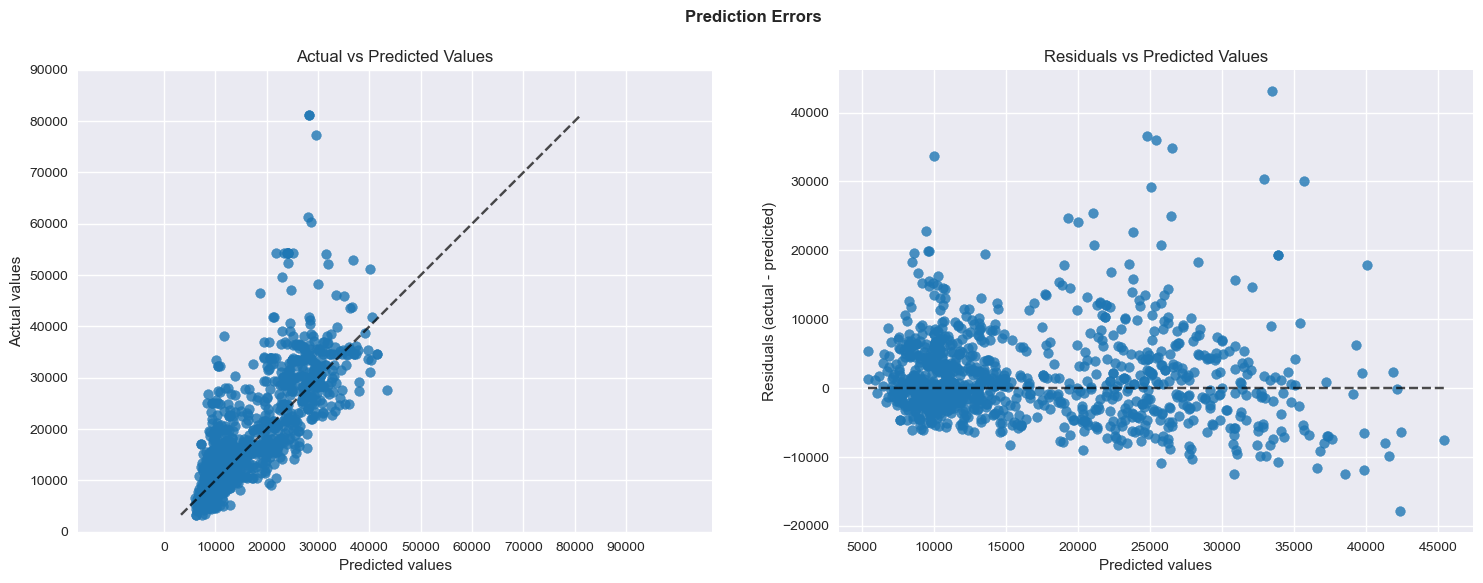

In [140]:
fig, axs = plt.subplots(1, 2, figsize=[18,6])
plt.suptitle("Prediction Errors", weight="bold")

PredictionErrorDisplay.from_predictions(y_test, preds, kind="actual_vs_predicted", ax=axs[0])
axs[0].set_title("Actual vs Predicted Values")
axs[0].set_yticks(np.linspace(0,90000,10))
axs[0].set_xticks(np.linspace(0,90000,10))
axs[0].set_xlim(0, 90000)
axs[0].set_ylim(0, 90000)


PredictionErrorDisplay.from_predictions(y_test, preds, kind="residual_vs_predicted", ax=axs[1])
axs[1].set_title("Residuals vs Predicted Values");
plt.savefig("Prediction_Errors.png", dpi=300)

In [154]:
coefficients = final_pipeline.named_steps["model"].regressor_.coef_
names = final_pipeline.named_steps["final_transformer"].get_feature_names_out()

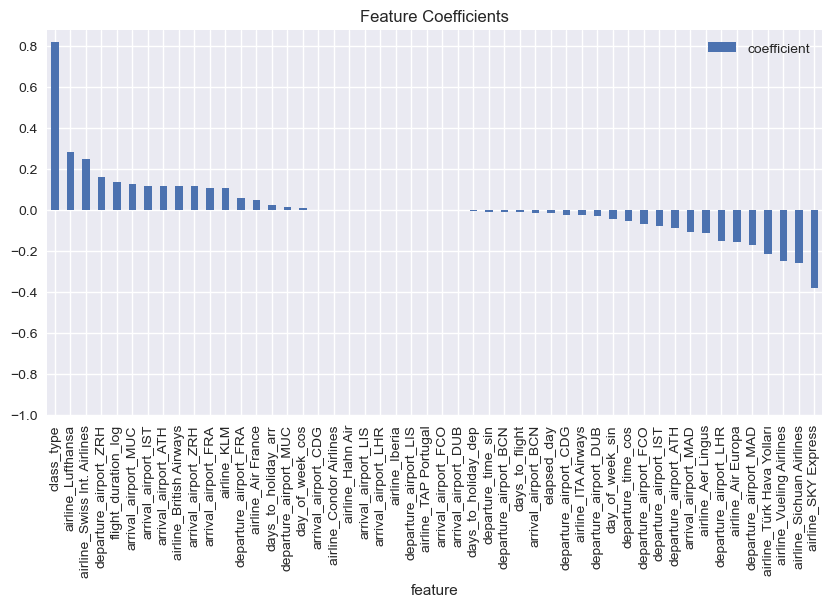

In [196]:
coef_df = pd.DataFrame({"feature": names,
                        "coefficient": coefficients}).sort_values("coefficient", ascending=False)
coef_df.plot(kind="bar", x="feature", y="coefficient", figsize=(10,5))
plt.yticks(np.arange(-1,1,0.2))
plt.title("Feature Coefficients");
plt.savefig("Feature_Coefs_1.png", dpi=300, bbox_inches="tight")

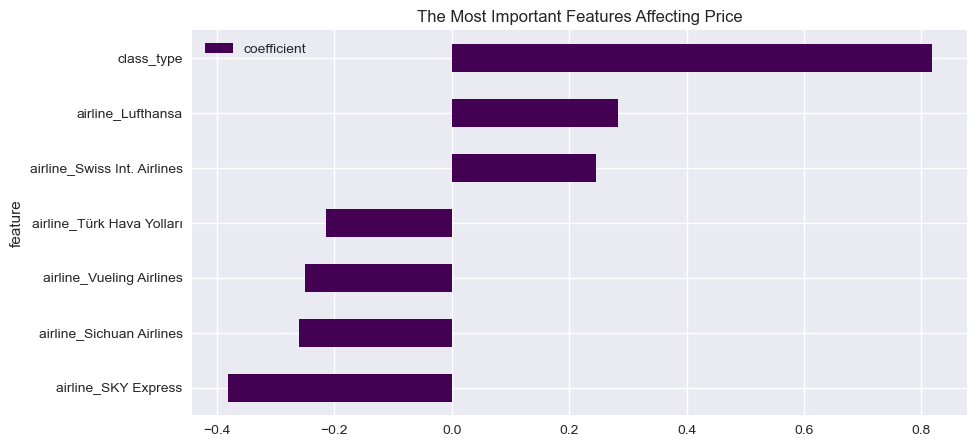

In [195]:
important_features = coef_df[(coef_df["coefficient"] > 0.2) | (coef_df["coefficient"] < -0.2)].sort_values("coefficient", ascending=True)

important_features.plot(kind="barh", x="feature", y="coefficient", figsize=(10,5), colormap="viridis")
plt.title("The Most Important Features Affecting Price");
plt.savefig("Feature_Coefs_2.png", dpi=300, bbox_inches="tight")

In [198]:
joblib.dump(final_pipeline, "model.pkl")

['model.pkl']

In [199]:
model = joblib.load("model.pkl")

In [200]:
model

,steps,"[('deterministic_final', ...), ('final_transformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('departure_time', ...), ('weekday_transform', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
